In [5]:
import os
import pandas as pd
import subprocess

# === Path to your main folder ===
base_path = r"D:\special_child_project\special_child_dataset"

# === List to store all data ===
data = []

# === Walk through all subfolders (handles folders inside folders too) ===
for root, dirs, files in os.walk(base_path):
    for file_name in files:
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            # Child name is the folder name containing the image
            child_name = os.path.basename(os.path.dirname(os.path.join(root, file_name)))
            
            # Full path of image
            full_path = os.path.join(root, file_name)
            
            # Add all info
            data.append({
                "Child_Name": child_name,
                "Image_File": file_name,
                "Full_Path": full_path,
                "Age": "",
                "Class": "",
                "Writing_Type": "",
                "Notes": ""
            })

# === Create a DataFrame ===
df = pd.DataFrame(data)

# === Save Excel inside the same folder as your dataset ===
output_path = os.path.join(base_path, "children_writing_data.xlsx")
df.to_excel(output_path, index=False)

print("✅ Excel file created successfully!")
print("📂 File saved at:", output_path)

# === Automatically open the Excel file ===
try:
    subprocess.Popen(["explorer", os.path.abspath(output_path)])
except Exception as e:
    print("⚠️ Could not open file automatically:", e)


PermissionError: [Errno 13] Permission denied: 'D:\\special_child_project\\special_child_dataset\\children_writing_data.xlsx'

In [6]:
import tensorflow as tf
from keras.utils import to_categorical

# Read Excel file
df = pd.read_excel("D:/special_child_project/children_writing_data_final.xlsx")

# Display first few rows to verify
print(df.head())


   S.No. Child_Name     Image_File  \
0      1       Aaru     banan.jpeg   
1      2       Aaru      bike.jpeg   
2      3       Aaru     black.jpeg   
3      4       Aaru  blue (2).jpeg   
4      5       Aaru      blue.jpeg   

                                           Full_Path Disability  IQ Level  \
0  D:\special_child_project\special_child_dataset...         MR        42   
1  D:\special_child_project\special_child_dataset...         MR        42   
2  D:\special_child_project\special_child_dataset...         MR        42   
3  D:\special_child_project\special_child_dataset...         MR        42   
4  D:\special_child_project\special_child_dataset...         MR        42   

   percentage of disability  age   Label  
0                        75   10  BANANA  
1                        75   10    BIKE  
2                        75   10   BLACK  
3                        75   10   BLUE   
4                        75   10    BLUE  


In [7]:
import cv2
# Read your Excel
df = pd.read_excel("D:/special_child_project/children_writing_data_final.xlsx")

# Fix the paths (replace \ with /)
df["Full_Path"] = df["Full_Path"].str.replace("\\", "/", regex=False)

# Now test one image
path = df["Full_Path"].iloc[0]
print("Fixed path:", path)
print("Exists?", os.path.exists(path))

img = cv2.imread(path)
print("Loaded image:", img is not None)

Fixed path: D:/special_child_project/special_child_dataset/Aaru/banan.jpeg
Exists? True
Loaded image: True


In [8]:
import numpy as np
IMG_SIZE = (128, 128)
images, labels = [], []

for idx, row in df.iterrows():
    path = row["Full_Path"]
    label = row["Label"]
    
    img = cv2.imread(path)
    if img is None:
        print(f"⚠️ Could not read {path}")
        continue
    
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0  # normalize
    
    images.append(img)
    labels.append(label)

X = np.array(images)
y = np.array(labels)

In [9]:
print(X.shape, y.shape)

(408, 128, 128, 3) (408,)


In [10]:
print(df.head())

   S.No. Child_Name     Image_File  \
0      1       Aaru     banan.jpeg   
1      2       Aaru      bike.jpeg   
2      3       Aaru     black.jpeg   
3      4       Aaru  blue (2).jpeg   
4      5       Aaru      blue.jpeg   

                                           Full_Path Disability  IQ Level  \
0  D:/special_child_project/special_child_dataset...         MR        42   
1  D:/special_child_project/special_child_dataset...         MR        42   
2  D:/special_child_project/special_child_dataset...         MR        42   
3  D:/special_child_project/special_child_dataset...         MR        42   
4  D:/special_child_project/special_child_dataset...         MR        42   

   percentage of disability  age   Label  
0                        75   10  BANANA  
1                        75   10    BIKE  
2                        75   10   BLACK  
3                        75   10   BLUE   
4                        75   10    BLUE  


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# For multi-class CNN classification
y_categorical = to_categorical(y_encoded)

print(le.classes_)  # check class names

['ANSHUL' 'ANSHUL ' 'ANUJ' 'APPLE' 'APPLE ' 'ASHOK' 'BANANA' 'BAT' 'BEAR'
 'BIKE' 'BLACK' 'BLUE' 'BLUE ' 'BUS' 'CAR' 'CAR ' 'CARRORT' 'CARROT'
 'CHEST' 'CHIRAG' 'CHIRAG ' 'CIRCLE' 'COW' 'CRICKET' 'CROW' 'DEER'
 'DOCTOR' 'DOG' 'EAR' 'EARS' 'ELEPHANT' 'EYE' 'EYES' 'EYES ' 'FOUR' 'FOX'
 'FRIDAY' 'GOAT' 'GRAPES' 'GREEN' 'GUAVA' 'HAIR' 'HAND' 'HEAR' 'HEN'
 'HOLI' 'IS' 'ISHITA' 'JEEP' 'JITENDER' 'LEG' 'LION' 'LIPS' 'LIPS '
 'LOTUS' 'LUDO' 'MANGO' 'MANGO ' 'MANOJ' 'MARIGOLD' 'MAT' 'MONDAY'
 'MONSOON' 'MOUTH' 'NAME' 'NAN' 'NOSE' 'NOSE ' 'ONION' 'ORANGE' 'ORANGE '
 'OWL' 'OX' 'PARROT' 'PARUL' 'PEA' 'PEAS' 'PINK' 'PINK ' 'PLEASE' 'POLICE'
 'POTATO' 'POTATO ' 'RADISH' 'RAIN' 'RECTANGLE' 'RED' 'ROSE' 'SATURDAY'
 'SCOOTY' 'SORRY' 'SQUARE' 'SUDESH' 'SUDHIR' 'SUMMAR' 'SUMMER' 'SUNDAY'
 'SUNFLOWER' 'SWAN' 'TAILOR' 'TEEJ' 'THURSDAY' 'TIGER' 'TOMATO' 'TRAIN'
 'TRUCK' 'TRUCK ' 'TUESDAY' 'TULIP' 'TWO' 'VAN' 'WEDNESDAY' 'WHITE'
 'YELLOW']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


d:\special_child_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 114)            │         7,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833,874 (3.18 MB)

 Trainable params: 833,874 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator( rescale=1./1., rotation_range=20, zoom_range=0.2, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True )

In [15]:
datagen.fit(X_train)

In [16]:
1e-4

0.0001

In [17]:
# from keras.models import Sequential
# from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AlphaDropout
# from keras.initializers import lecun_normal
# from keras.callbacks import EarlyStopping
# # from keras.callbacks import ReduceLROnPlateau

# # lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# import keras

# # --- Model Definition ---
# model = Sequential([
#     Conv2D(16, (3,3), activation='selu', kernel_initializer='lecun_normal', input_shape=(128,128,3)),
#     MaxPooling2D(2,2),

#     Conv2D(32, (3,3), activation='selu', kernel_initializer='lecun_normal'),
#     MaxPooling2D(2,2),

#     Conv2D(64, (3,3), activation='selu', kernel_initializer='lecun_normal'),
#     MaxPooling2D(2,2),

#     Flatten(),

#     Dense(64, activation='selu', kernel_initializer='lecun_normal'),
#     AlphaDropout(0.3),

#     Dense(len(le.classes_), activation='softmax')
# ])
# # --- Compile ---
# model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# # --- Early Stopping ---
# # early_stop = EarlyStopping(
# #     monitor='val_loss',
# #     patience=10,              # stop after 10 epochs with no improvement
# #     restore_best_weights=True
# # )

# # --- Train ---
# history = model.fit(
#     datagen.flow(X_train, y_train, batch_size=32),
#     validation_data=(X_test, y_test),
#     epochs=1000,
#     batch_size=8,
# )

# # --- Summary ---
# model.summary()


In [18]:
from keras.applications import MobileNetV2
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # freeze pre-trained layers

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(114, activation='softmax')  # your 100 classes
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     5,243,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 114)            │        29,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,530,418 (28.73 MB)

 Trainable params: 5,272,434 (20.11 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=16),
                    validation_data=(X_test, y_test),
                    epochs=250)

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 308ms/step - accuracy: 0.0307 - loss: 5.5136 - val_accuracy: 0.0244 - val_loss: 4.7271
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.0399 - loss: 4.6288 - val_accuracy: 0.0976 - val_loss: 4.5672
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.0613 - loss: 4.5135 - val_accuracy: 0.0854 - val_loss: 4.4952
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.0982 - loss: 4.3962 - val_accuracy: 0.0976 - val_loss: 4.4235
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 251ms/step - accuracy: 0.0675 - loss: 4.3496 - val_accuracy: 0.1098 - val_loss: 4.4604
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 0.0736 - loss: 4.3273 - val_accuracy: 0.1098 - val_loss: 4.4150
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step - accuracy: 0.1043 - loss: 4.1320 - val_accuracy: 0.1341 - val_loss: 4.2390
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.1288 - loss: 4.1000 - val_acc

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_acc:.2f}")
print(f"❌ Test Loss: {test_loss:.2f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.3780 - loss: 5.1813
✅ Test Accuracy: 0.38
❌ Test Loss: 5.18


In [ ]:
import numpy as np

predictions = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

true_labels = le.inverse_transform(y_true)
pred_labels = le.inverse_transform(y_pred)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 772ms/step


In [ ]:
for i in range(10):
    print(f"Image {i+1}: True → {true_labels[i]} | Predicted → {pred_labels[i]}")


Image 1: True → PINK  | Predicted → PINK
Image 2: True → POLICE | Predicted → RAIN
Image 3: True → GUAVA | Predicted → GUAVA
Image 4: True → ANSHUL  | Predicted → ANSHUL
Image 5: True → APPLE | Predicted → APPLE 
Image 6: True → THURSDAY | Predicted → ANSHUL
Image 7: True → EYE | Predicted → BUS
Image 8: True → NOSE | Predicted → NOSE
Image 9: True → PARUL | Predicted → ASHOK
Image 10: True → ONION | Predicted → SWAN


In [ ]:
for i in range(5):
    probs = list(zip(le.classes_, predictions[i]))
    probs_sorted = sorted(probs, key=lambda x: x[1], reverse=True)
    print(f"\nImage {i+1}:")
    for label, prob in probs_sorted[:3]:
        print(f"{label}: {prob:.2f}")



Image 1:
PINK: 0.76
PINK : 0.13
DOG: 0.04

Image 2:
RAIN: 0.23
ANSHUL: 0.15
PLEASE: 0.15

Image 3:
GUAVA: 0.63
CARROT: 0.13
RADISH: 0.08

Image 4:
ANSHUL: 0.99
ANSHUL : 0.00
APPLE : 0.00

Image 5:
APPLE : 0.82
APPLE: 0.15
PINK: 0.01


In [ ]:
top_label = le.classes_[np.argmax(predictions[i])]
top_confidence = np.max(predictions[i])

print(f"Predicted word: {top_label} (confidence: {top_confidence:.2f})")


Predicted word: APPLE  (confidence: 0.82)


In [ ]:
from collections import defaultdict

mistake_counts = defaultdict(lambda: defaultdict(int))

for i in range(len(X_test)):
    true_word = le.inverse_transform([np.argmax(y_test[i])])[0]
    predicted_word = le.inverse_transform([np.argmax(predictions[i])])[0]
    child = df.loc[i, "Child_Name"]

    for t, p in zip(true_word, predicted_word):
        if t != p:
            mistake_counts[child][t] += 1


In [ ]:
print(dict(mistake_counts))

{'Aaru': defaultdict(<class 'int'>, {'P': 4, 'O': 5, 'L': 4, 'I': 4, 'T': 3, 'H': 1, 'U': 3, 'R': 6, 'S': 2, 'D': 3, 'E': 8, 'Y': 1, 'A': 6, 'N': 4, 'G': 3, 'C': 1}), 'Akash': defaultdict(<class 'int'>, {'B': 2, 'A': 10, 'D': 1, 'O': 7, 'C': 2, 'T': 2, 'R': 2, 'M': 4, 'I': 3, 'L': 2, 'H': 1, 'G': 4, 'N': 3, 'K': 1, 'U': 1, 'V': 1, 'P': 1, 'S': 1, 'E': 2}), 'chirag': defaultdict(<class 'int'>, {'G': 3, 'O': 4, 'A': 6, 'N': 6, 'C': 2, 'I': 4, 'R': 5, 'E': 6, 'P': 4, 'K': 1, 'H': 3, 'L': 2, 'S': 2, 'U': 3, 'D': 4, 'Y': 2, 'T': 1, 'W': 1, 'Q': 1})}


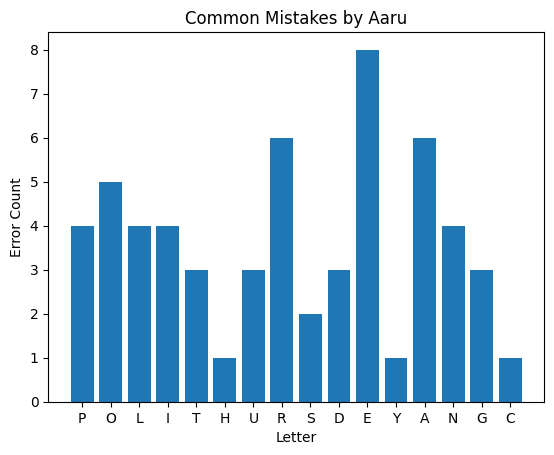

In [ ]:
import matplotlib.pyplot as plt

child = "Aaru"
letters = list(mistake_counts[child].keys())
errors = list(mistake_counts[child].values())

plt.bar(letters, errors)
plt.title(f"Common Mistakes by {child}")
plt.xlabel("Letter")
plt.ylabel("Error Count")
plt.show()


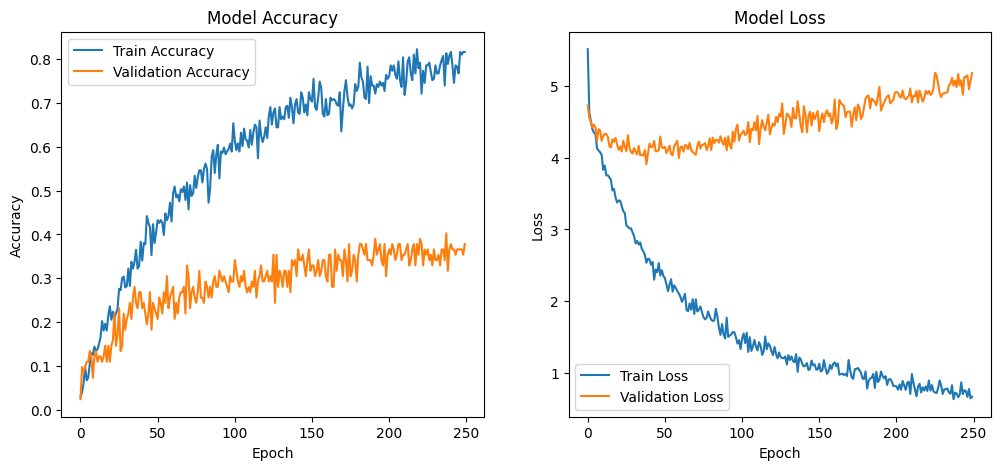

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_acc:.2f}")
print(f"❌ Test Loss: {test_loss:.2f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.3780 - loss: 5.1813
✅ Test Accuracy: 0.38
❌ Test Loss: 5.18


In [ ]:
import numpy as np

predictions = model.predict(X_train)
y_true = np.argmax(y_train, axis=1)
y_pred = np.argmax(predictions, axis=1)

true_labels = le.inverse_transform(y_true)
pred_labels = le.inverse_transform(y_pred)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step


In [ ]:
for i in range(10):
    print(f"Image {i+1}: True → {true_labels[i]} | Predicted → {pred_labels[i]}")


Image 1: True → LION | Predicted → LION
Image 2: True → BLUE  | Predicted → BLUE 
Image 3: True → NOSE  | Predicted → NOSE 
Image 4: True → BANANA | Predicted → BANANA
Image 5: True → APPLE | Predicted → APPLE
Image 6: True → PINK | Predicted → PINK
Image 7: True → FRIDAY | Predicted → FRIDAY
Image 8: True → BLACK | Predicted → BLACK
Image 9: True → DOCTOR | Predicted → DOCTOR
Image 10: True → COW | Predicted → COW


d:\special_child_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\special_child_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\special_child_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      ANSHUL       0.94      1.00      0.97        15
     ANSHUL        1.00      1.00      1.00         6
        ANUJ       1.00      1.00      1.00         1
       APPLE       1.00      1.00      1.00        10
      APPLE        1.00      1.00      1.00         3
       ASHOK       1.00      1.00      1.00         3
      BANANA       1.00      1.00      1.00        10
         BAT       1.00      1.00      1.00         1
        BEAR       1.00      1.00      1.00         2
        BIKE       1.00      0.67      0.80         3
       BLACK       1.00      1.00      1.00         8
        BLUE       1.00      1.00      1.00        11
       BLUE        1.00      1.00      1.00         1
         BUS       0.75      1.00      0.86         6
         CAR       1.00      1.00      1.00         7
        CAR        1.00      1.00      1.00         1
     CARRORT       1.00      1.00      1.00         1
      CARROT       1.00    

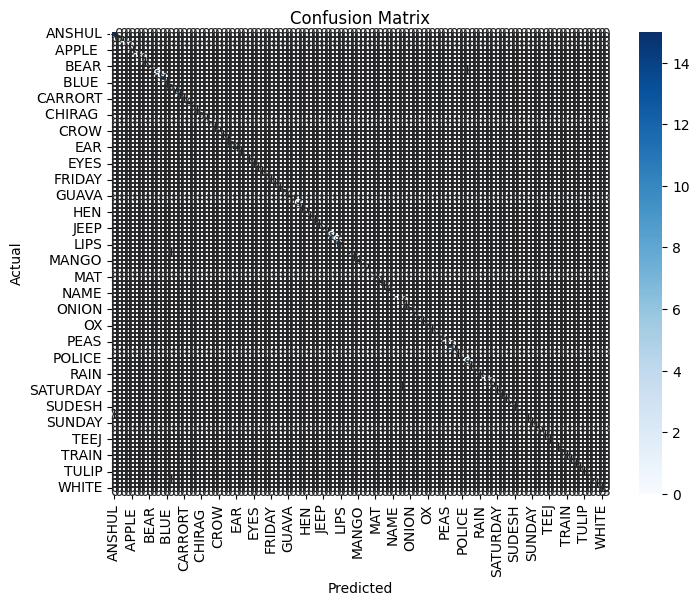

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

print(classification_report(true_labels, pred_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=le.classes_)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
for i in range(5):
    probs = list(zip(le.classes_, predictions[i]))
    probs_sorted = sorted(probs, key=lambda x: x[1], reverse=True)
    print(f"\nImage {i+1}:")
    for label, prob in probs_sorted[:3]:
        print(f"{label}: {prob:.2f}")



Image 1:
LION: 1.00
APPLE: 0.00
BLUE: 0.00

Image 2:
BLUE : 0.99
GRAPES: 0.00
ORANGE : 0.00

Image 3:
NOSE : 0.96
LION: 0.03
NOSE: 0.00

Image 4:
BANANA: 1.00
ORANGE : 0.00
MONDAY: 0.00

Image 5:
APPLE: 0.97
ASHOK: 0.01
ANSHUL: 0.00


In [ ]:
model.save('model.h5')
print("✅ Model saved as model.h5")

✅ Model saved as model.h5


In [ ]:
from tensorflow import keras
import numpy as np

# Load and verify
loaded_model = keras.models.load_model('model.h5', compile=False)
print(f"✅ Model loaded successfully!")
print(f"   Input shape: {loaded_model.input_shape}")
print(f"   Output shape: {loaded_model.output_shape}")
print(f"   Total parameters: {loaded_model.count_params():,}")

✅ Model loaded successfully!
   Input shape: (None, 128, 128, 3)
   Output shape: (None, 114)
   Total parameters: 7,530,418


In [ ]:
dummy_input = np.random.rand(1, *loaded_model.input_shape[1:]).astype(np.float32)
dummy_output = loaded_model.predict(dummy_input, verbose=0)
print(f"   Test prediction shape: {dummy_output.shape}")
print(f"   Number of classes: {dummy_output.shape[1]}")

   Test prediction shape: (1, 114)
   Number of classes: 114


In [ ]:
CLASS_LABELS = ['ANSHUL', 'ANUJ', 'APPLE', 'ASHOK', 'BANANA', 'BAT', 'BEAR', 'BIKE', 'BLACK', 
                'BLUE', 'BUS', 'CAR', 'CARROT', 'CHEST', 'CHIRAG', 'CIRCLE', 'COW', 'CRICKET', 
                'CROW', 'DEER', 'DOCTOR', 'DOG', 'EAR', 'EARS', 'ELEPHANT', 'EYE', 'EYES', 
                'FOUR', 'FOX', 'FRIDAY', 'GOAT', 'GRAPES', 'GREEN', 'GUAVA', 'HAIR', 'HAND', 
                'HEAR', 'HEN', 'HOLI', 'IS', 'ISHITA', 'JEEP', 'JITENDER', 'LEG', 'LION', 
                'LIPS', 'LOTUS', 'LUDO', 'MANGO', 'MANOJ', 'MARIGOLD', 'MAT', 'MONDAY', 
                'MONSOON', 'MOUTH', 'NAME', 'NAN', 'NOSE', 'ONION', 'ORANGE', 'OWL', 'OX', 
                'PARROT', 'PARUL', 'PEA', 'PEAS', 'PINK', 'PLEASE', 'POLICE', 'POTATO', 
                'RADISH', 'RAIN', 'RECTANGLE', 'RED', 'ROSE', 'SATURDAY', 'SCOOTY', 'SORRY', 
                'SQUARE', 'SUDESH', 'SUDHIR', 'SUMMAR', 'SUMMER', 'SUNDAY', 'SUNFLOWER', 
                'SWAN', 'TAILOR', 'TEEJ', 'THURSDAY', 'TIGER', 'TOMATO', 'TRAIN', 'TRUCK', 
                'TUESDAY', 'TULIP', 'TWO', 'VAN', 'WEDNESDAY', 'WHITE', 'YELLOW']

print(f"\n📊 Expected number of classes: {len(CLASS_LABELS)}")
print(f"   Model output classes: {dummy_output.shape[1]}")

if len(CLASS_LABELS) == dummy_output.shape[1]:
    print("✅ Class count matches!")
else:
    print("⚠️ WARNING: Class count mismatch!")
    print("   Please update CLASS_LABELS in app_enhanced_fixed.py to match your model")

# ============================================
# PRINT MODEL SUMMARY
# ============================================
print("\n📋 Model Architecture:")
loaded_model.summary()


📊 Expected number of classes: 100
   Model output classes: 114
⚠️ WARNING: Class count mismatch!
   Please update CLASS_LABELS in app_enhanced_fixed.py to match your model

📋 Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     5,243,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 114)            │        29,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,530,418 (28.73 MB)

 Trainable params: 5,272,434 (20.11 MB)

 Non-trainable params: 2,257,984 (8.61 MB)